# Structural Break Analysis of German aFRR Markets

## Objective

This notebook analyzes how major market and system events changed the relationship between renewable/load drivers and aFRR activation prices in Germany. The workflow is structured for academic reproducibility and direct use in a Master's thesis.

## Data Source and Events

**Data source:** `data/processed/all_data_clean.parquet`  
**Target variables:** `afrr_avg_activation_price_pos`, `afrr_avg_activation_price_neg`  
**Driver feature (correlation):** `wind_onshore_error`

Analyzed events:

1. **RAM start (Regelarbeitsmarkt):** 2020-11-02
2. **PICASSO go-live:** 2022-06-01
3. **Energy crisis peak:** 2022-08-01 to 2022-12-31
4. **Nuclear phase-out:** 2023-04-15

Note: The available dataset starts after the RAM event. RAM is therefore shown as a reference line only.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

from energy_trading.visualization.style import apply_geo_style, ROLE_COLORS, GEO_DIVERGING

apply_geo_style()
sns.set_theme(style='whitegrid', context='talk')

In [2]:
DATA_PATH = Path('../data/processed/all_data_clean.parquet')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'File not found: {DATA_PATH}')

df = pd.read_parquet(DATA_PATH)

df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)
df = df.sort_values('timestamp_utc').reset_index(drop=True)

required_cols = [
    'wind_onshore_error',
    'afrr_avg_activation_price_pos',
    'afrr_avg_activation_price_neg',
    'residual_load_actual',
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f'Fehlende Spalten: {missing}')

analysis_df = df[['timestamp_utc'] + required_cols].copy()

print('Rows:', len(analysis_df))
print('Time range:', analysis_df['timestamp_utc'].min(), '->', analysis_df['timestamp_utc'].max())
print('Null values (relevant columns):')
print(analysis_df[required_cols].isna().sum())

Rows: 44568
Time range: 2020-11-30 23:00:00+00:00 -> 2025-12-31 23:00:00+00:00
Null values (relevant columns):
wind_onshore_error               0
afrr_avg_activation_price_pos    0
afrr_avg_activation_price_neg    0
residual_load_actual             0
dtype: int64


In [3]:
EVENTS = {
    'RAM Start': pd.Timestamp('2020-11-02T00:00:00Z'),
    'PICASSO Go-Live': pd.Timestamp('2022-06-01T00:00:00Z'),
    'Nuclear phase-out': pd.Timestamp('2023-04-15T00:00:00Z'),
}

CRISIS_START = pd.Timestamp('2022-08-01T00:00:00Z')
CRISIS_END = pd.Timestamp('2022-12-31T23:00:00Z')

POINT_WINDOW_DAYS = 180


def _point_event_windows(df_in: pd.DataFrame, event_ts: pd.Timestamp, days: int = 180):
    before_mask = (df_in['timestamp_utc'] >= event_ts - pd.Timedelta(days=days)) & (df_in['timestamp_utc'] < event_ts)
    after_mask = (df_in['timestamp_utc'] >= event_ts) & (df_in['timestamp_utc'] < event_ts + pd.Timedelta(days=days))
    return df_in.loc[before_mask], df_in.loc[after_mask]


def _range_event_windows(df_in: pd.DataFrame, start_ts: pd.Timestamp, end_ts: pd.Timestamp):
    duration = end_ts - start_ts + pd.Timedelta(hours=1)
    before_mask = (df_in['timestamp_utc'] >= start_ts - duration) & (df_in['timestamp_utc'] < start_ts)
    during_mask = (df_in['timestamp_utc'] >= start_ts) & (df_in['timestamp_utc'] <= end_ts)
    after_mask = (df_in['timestamp_utc'] > end_ts) & (df_in['timestamp_utc'] <= end_ts + duration)
    return df_in.loc[before_mask], df_in.loc[during_mask], df_in.loc[after_mask]

## 1) 30-day Rolling Correlation

The time-varying correlation between `wind_onshore_error` and `afrr_avg_activation_price_pos` is computed using a 30-day hourly rolling window. Events are shown as vertical markers, and the energy crisis period is highlighted.

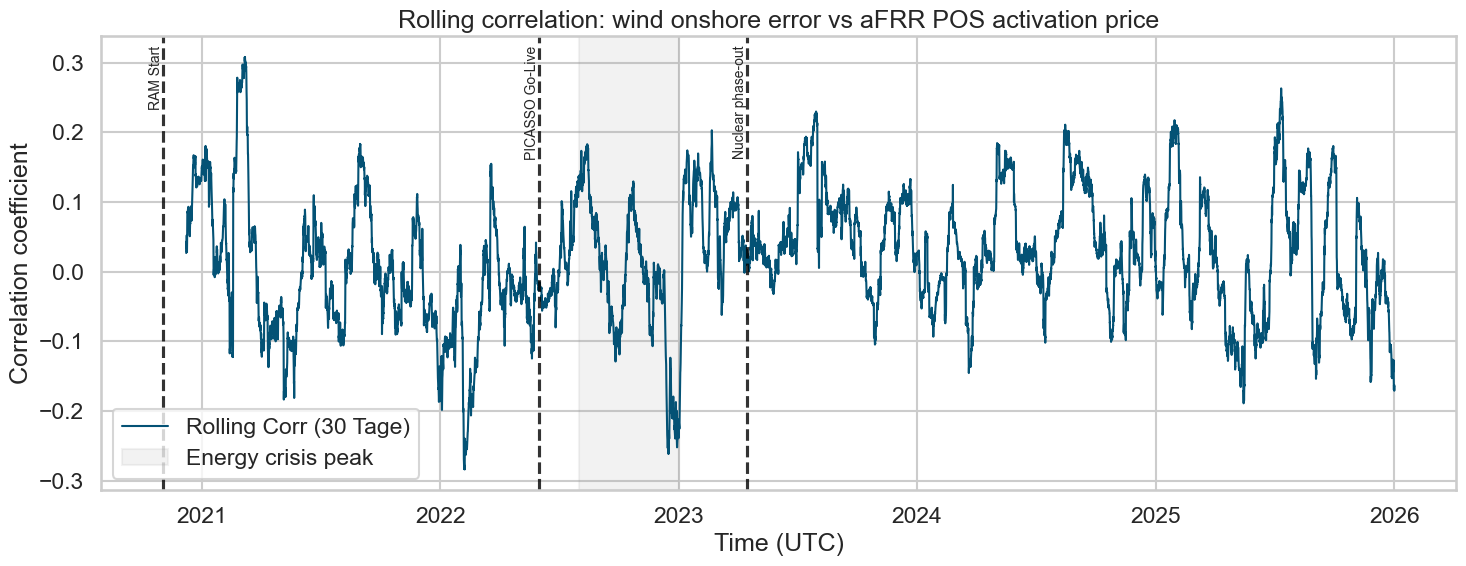

In [4]:
corr_df = analysis_df.set_index('timestamp_utc')[['wind_onshore_error', 'afrr_avg_activation_price_pos']].dropna()
rolling_hours = 24 * 30
corr_df['rolling_corr_30d'] = corr_df['wind_onshore_error'].rolling(rolling_hours, min_periods=24*7).corr(corr_df['afrr_avg_activation_price_pos'])

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(corr_df.index, corr_df['rolling_corr_30d'], color=ROLE_COLORS['load'], linewidth=1.5, label='Rolling Corr (30 Tage)')

for name, ts in EVENTS.items():
    ax.axvline(ts, color='black', linestyle='--', alpha=0.8)
    ax.text(ts, 0.98, name, rotation=90, va='top', ha='right', transform=ax.get_xaxis_transform(), fontsize=10)

ax.axvspan(CRISIS_START, CRISIS_END, color=ROLE_COLORS['benchmark_profit'], alpha=0.12, label='Energy crisis peak')

ax.set_title('Rolling correlation: wind onshore error vs aFRR POS activation price')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Correlation coefficient')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 2) Distribution Comparison Before/After Events

For each event, the distribution of activation prices (`pos`, `neg`) is compared in before/after windows. For the energy crisis event, the crisis window is analyzed explicitly as a separate phase.

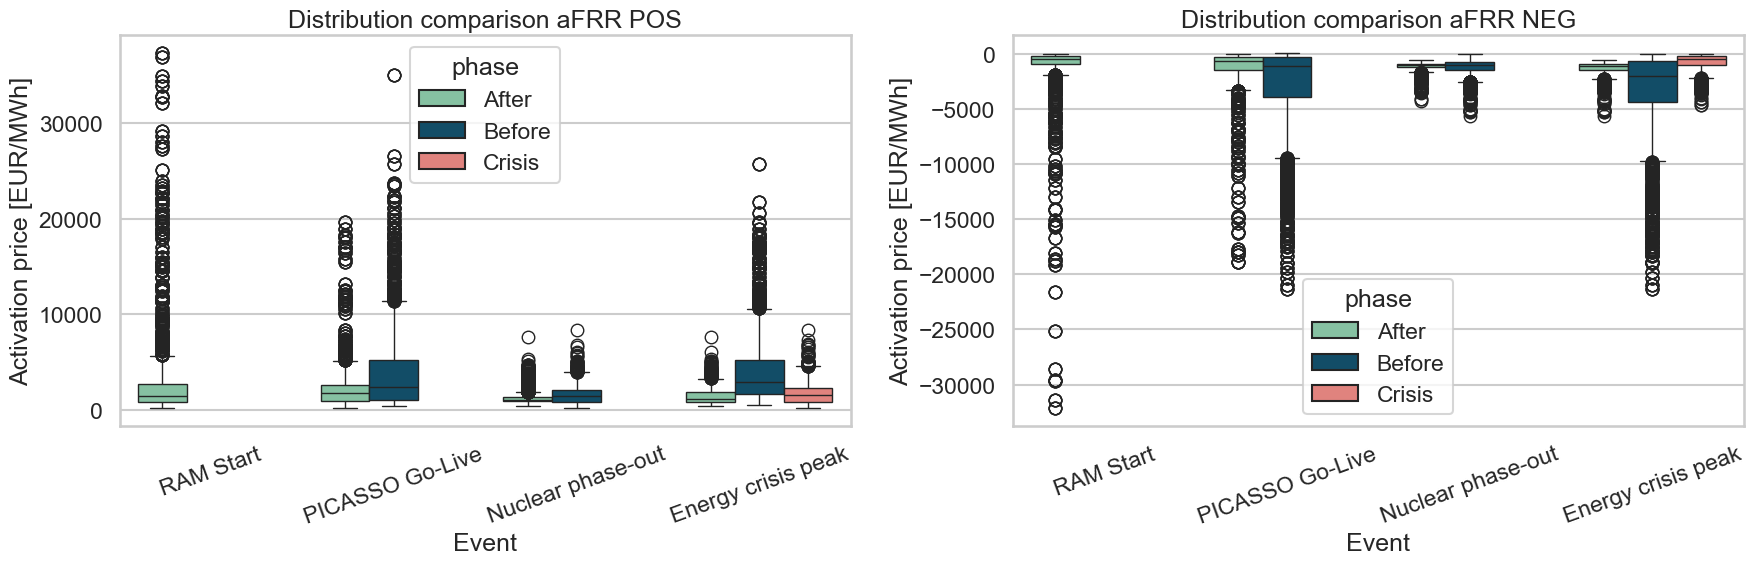

,event,side,comparison,n_before,n_after,median_before,median_after,p_value
6,Energy crisis peak,NEG,Before vs Crisis,3672,3672,-2003.15500,-496.12500,0.000000e+00
7,Energy crisis peak,NEG,Crisis vs After,3672,3672,-496.12500,-1074.72125,0.000000e+00
2,Energy crisis peak,POS,Before vs Crisis,3672,3672,2898.05375,1536.81000,9.533532e-302
3,Energy crisis peak,POS,Crisis vs After,3672,3672,1536.81000,1128.36750,1.006239e-26
5,Nuclear phase-out,NEG,Before vs After,4320,4320,-1009.68750,-1032.86500,3.124484e-07
1,Nuclear phase-out,POS,Before vs After,4320,4320,1448.32375,1081.39125,2.207441e-65
4,PICASSO Go-Live,NEG,Before vs After,4320,4320,-1104.47000,-607.14750,1.151155e-63
0,PICASSO Go-Live,POS,Before vs After,4320,4320,2387.30500,1794.31000,2.554054e-74


In [5]:
records = []

# Point events
for event_name, event_ts in EVENTS.items():
    before, after = _point_event_windows(analysis_df, event_ts, days=POINT_WINDOW_DAYS)
    for label, part in [('Before', before), ('After', after)]:
        for side, col in [('POS', 'afrr_avg_activation_price_pos'), ('NEG', 'afrr_avg_activation_price_neg')]:
            tmp = part[['timestamp_utc', col]].dropna().rename(columns={col: 'price'})
            tmp['event'] = event_name
            tmp['phase'] = label
            tmp['side'] = side
            records.append(tmp)

# Range-Event Energiekrise
before, during, after = _range_event_windows(analysis_df, CRISIS_START, CRISIS_END)
for label, part in [('Before', before), ('Crisis', during), ('After', after)]:
    for side, col in [('POS', 'afrr_avg_activation_price_pos'), ('NEG', 'afrr_avg_activation_price_neg')]:
        tmp = part[['timestamp_utc', col]].dropna().rename(columns={col: 'price'})
        tmp['event'] = 'Energy crisis peak'
        tmp['phase'] = label
        tmp['side'] = side
        records.append(tmp)

plot_df = pd.concat(records, ignore_index=True)

phase_palette = {'Before': GEO_DIVERGING['div_1'], 'After': GEO_DIVERGING['div_3'], 'Crisis': GEO_DIVERGING['div_5']}
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
for ax, side in zip(axes, ['POS', 'NEG']):
    sns.boxplot(
        data=plot_df[plot_df['side'] == side],
        x='event', y='price', hue='phase', palette=phase_palette, ax=ax
    )
    ax.set_title(f'Distribution comparison aFRR {side}')
    ax.set_xlabel('Event')
    ax.set_ylabel('Activation price [EUR/MWh]')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Non-parametric significance test (Mann-Whitney U)
stats_rows = []
for side, col in [('POS', 'afrr_avg_activation_price_pos'), ('NEG', 'afrr_avg_activation_price_neg')]:
    # Point events
    for event_name, event_ts in EVENTS.items():
        b, a = _point_event_windows(analysis_df[['timestamp_utc', col]], event_ts, days=POINT_WINDOW_DAYS)
        x = b[col].dropna()
        y = a[col].dropna()
        if len(x) > 10 and len(y) > 10:
            u, p = mannwhitneyu(x, y, alternative='two-sided')
            stats_rows.append({
                'event': event_name,
                'side': side,
                'comparison': 'Before vs After',
                'n_before': len(x),
                'n_after': len(y),
                'median_before': x.median(),
                'median_after': y.median(),
                'p_value': p,
            })
    # Energiekrise: Vorher vs Krise, Krise vs Nachher
    b, d, a = _range_event_windows(analysis_df[['timestamp_utc', col]], CRISIS_START, CRISIS_END)
    pairs = [('Before vs Crisis', b[col].dropna(), d[col].dropna()), ('Crisis vs After', d[col].dropna(), a[col].dropna())]
    for cmp_name, x, y in pairs:
        if len(x) > 10 and len(y) > 10:
            u, p = mannwhitneyu(x, y, alternative='two-sided')
            stats_rows.append({
                'event': 'Energy crisis peak',
                'side': side,
                'comparison': cmp_name,
                'n_before': len(x),
                'n_after': len(y),
                'median_before': x.median(),
                'median_after': y.median(),
                'p_value': p,
            })

stats_df = pd.DataFrame(stats_rows).sort_values(['event', 'side', 'comparison'])
stats_df

## 3) Volatility by Market Regime

To assess structural breaks, the standard deviation of activation prices is compared across market regimes.

In [6]:
reg = analysis_df.copy()

conditions = [
    reg['timestamp_utc'] < pd.Timestamp('2022-06-01T00:00:00Z'),
    (reg['timestamp_utc'] >= pd.Timestamp('2022-06-01T00:00:00Z')) & (reg['timestamp_utc'] < pd.Timestamp('2022-08-01T00:00:00Z')),
    (reg['timestamp_utc'] >= pd.Timestamp('2022-08-01T00:00:00Z')) & (reg['timestamp_utc'] <= pd.Timestamp('2022-12-31T23:00:00Z')),
    (reg['timestamp_utc'] >= pd.Timestamp('2023-01-01T00:00:00Z')) & (reg['timestamp_utc'] < pd.Timestamp('2023-04-15T00:00:00Z')),
    reg['timestamp_utc'] >= pd.Timestamp('2023-04-15T00:00:00Z'),
]
choices = [
    'Pre-PICASSO',
    'Early PICASSO',
    'Energy crisis',
    'Post-crisis / pre phase-out',
    'Post phase-out',
]
reg['regime'] = np.select(conditions, choices, default='Other')

vol = reg.groupby('regime', as_index=False).agg(
    std_pos=('afrr_avg_activation_price_pos', 'std'),
    std_neg=('afrr_avg_activation_price_neg', 'std'),
    mean_pos=('afrr_avg_activation_price_pos', 'mean'),
    mean_neg=('afrr_avg_activation_price_neg', 'mean'),
    n_obs=('timestamp_utc', 'count'),
)
vol = vol.set_index('regime').loc[choices].reset_index()
vol

,regime,std_pos,std_neg,mean_pos,mean_neg,n_obs
0,Pre-PICASSO,4069.206290,3213.889913,2779.994575,-1601.826032,13128
1,Early PICASSO,3362.134011,3429.202455,3457.895282,-2552.365253,1464
2,Energy crisis,1011.092300,668.886499,1701.230007,-711.760413,3672
3,Post-crisis / pre phase-out,739.412440,614.470531,1516.525474,-1338.010773,2496
4,Post phase-out,549.604580,417.441314,1399.589713,-1259.624212,23808


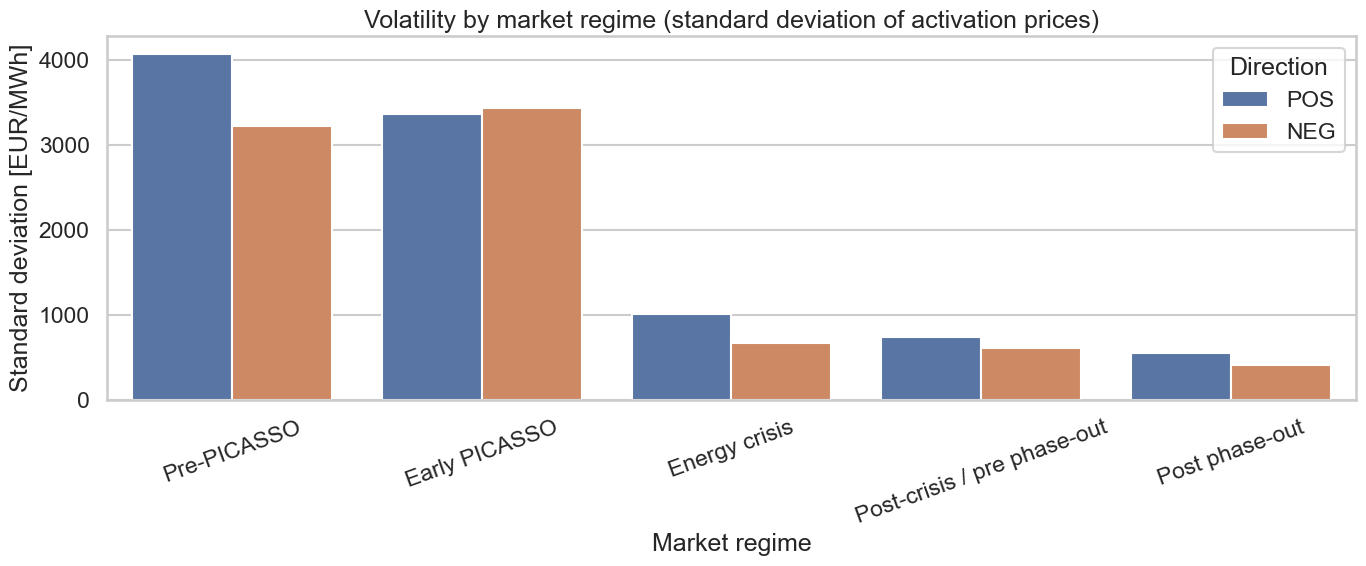

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
vol_melt = vol.melt(id_vars='regime', value_vars=['std_pos', 'std_neg'], var_name='side', value_name='std')
vol_melt['side'] = vol_melt['side'].map({'std_pos': 'POS', 'std_neg': 'NEG'})

sns.barplot(data=vol_melt, x='regime', y='std', hue='side', ax=ax)
ax.set_title('Volatility by market regime (standard deviation of activation prices)')
ax.set_xlabel('Market regime')
ax.set_ylabel('Standard deviation [EUR/MWh]')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Direction')
plt.tight_layout()
plt.show()

## 4) Scatter Analysis: Merit-Order Shift

Relationship between `residual_load_actual` and activation prices across market regimes (color-coded).

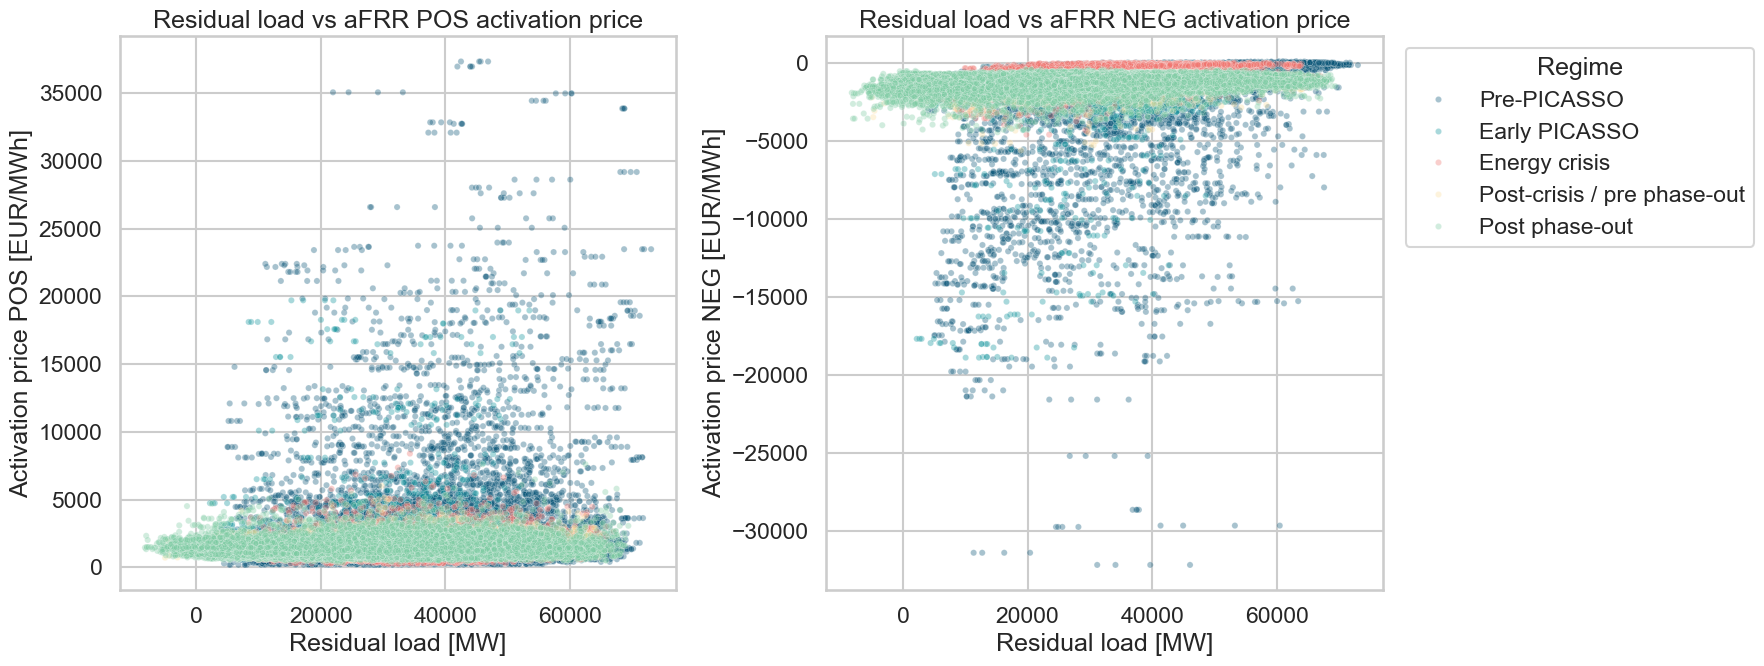

In [8]:
scatter_df = reg[['timestamp_utc', 'regime', 'residual_load_actual', 'afrr_avg_activation_price_pos', 'afrr_avg_activation_price_neg']].dropna()
if len(scatter_df) > 60000:
    scatter_df = scatter_df.sample(60000, random_state=42)

regime_palette = {
    'Pre-PICASSO': GEO_DIVERGING['div_1'],
    'Early PICASSO': GEO_DIVERGING['div_2'],
    'Energy crisis': GEO_DIVERGING['div_5'],
    'Post-crisis / pre phase-out': GEO_DIVERGING['div_4'],
    'Post phase-out': GEO_DIVERGING['div_3'],
    'Other': '#999999',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

sns.scatterplot(
    data=scatter_df,
    x='residual_load_actual',
    y='afrr_avg_activation_price_pos',
    hue='regime',
    alpha=0.35,
    s=20,
    palette=regime_palette,
    ax=axes[0],
)
axes[0].set_title('Residual load vs aFRR POS activation price')
axes[0].set_xlabel('Residual load [MW]')
axes[0].set_ylabel('Activation price POS [EUR/MWh]')

sns.scatterplot(
    data=scatter_df,
    x='residual_load_actual',
    y='afrr_avg_activation_price_neg',
    hue='regime',
    alpha=0.35,
    s=20,
    palette=regime_palette,
    ax=axes[1],
)
axes[1].set_title('Residual load vs aFRR NEG activation price')
axes[1].set_xlabel('Residual load [MW]')
axes[1].set_ylabel('Activation price NEG [EUR/MWh]')

# Show one legend on the right
handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend(handles=handles, labels=labels, title='Regime', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Summary and Recommendation for ML Training

The results should be interpreted along three key dimensions:

1. **Regime breaks are visible:** Especially around PICASSO go-live and during the energy crisis, both price levels and distributions shift.
2. **Volatility is regime-dependent:** A single model over all years can only partially capture structural breaks.
3. **Merit-order relationships are non-stationary:** The relationship between residual load and activation prices changes across phases.

**Recommendation for model training:**

- Preferred training window for robust operational modeling: **post-crisis and post phase-out (from 2023-04-15 onward)**.
- For broad generalization, use either:
  - regime-specific models, or
  - one global model with explicit regime/event features.
- Treat the energy crisis period (2022-08 to 2022-12) as a **stress-test set**, not as the sole baseline training period.